# Relacion 3 Nanoelectrónica

### Ejercicio 3.1: Realizar el ejercicio 3.9

##### Apartado a
**Calcular la intensidad y la conductancia para un sistema con solo un Homo y $C_{ES} -> \infty$**

In [12]:
### LIBRERÍAS #################

from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt

In [13]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 


In [14]:
### Definición de parámetros para los ejercicios ############################3


Ef_0 = -5.0     #eV
Eta = 0.5       
homo = -5.5     #eV
Gamma_s = 0.1   #eV
Gamma_d = 0.1   #eV
T=298           #K
mu_s0 = -5      #eV
mu_d0 = -5      #eV
lumo = -1.5     #eV

KT =0.026*T/300 #eV

q_C_es = 1      #eV

Vmax = 4        #eV

numpasos = 801  #Cantidad de pasos desde -Vmax hasta Vmax

precision = 10**(-4)    #Precisión a la hora de converger U
alfa = 0.05              #Constante para la convergencia (Para valores mayores a 0.15 daba resultados raros)
N_0 = 2                 #Número de electrones del homo



In [15]:
### Código para el ejercicio 3.1 #############################################


#Calculamos la función de fermi


def fermi(energia, e_fermi):
    """
    Args:
        energia (Float): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    
    resultado = 1/(1+np.exp((energia - e_fermi)/KT))
    return resultado


#print(fermi(Ef, Ef)) (Debe dar un medio)

#Calculamos Tau_s y Tau_D

Tau_s = hbar / Gamma_s
Tau_d = hbar / Gamma_d

#Voy a hacer un bucle barriendo los voltajes.
#Empezaré en un voltaje grande negativo y acabaré en uno grande positivo.
#Para cada voltaje hay que calcularlo todo: N, 

#Calculamos el número de electrones N.
#Como solo hay un nivel y g es una delta multiplico por 2 y me quito la integral.
#No usaremos el nivel de fermi, sino una función escalón


V = np.linspace(-Vmax, Vmax, numpasos)
N = np.linspace(-Vmax, Vmax, numpasos)

for i, v in enumerate(V):
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    N[i] = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo,mu_s) + Tau_s*fermi(homo, mu_d))
    
    

### Calculo ahora la intensidad y conductancia #######################################################

#Como solo hay un nivel homo y Gamma -> 0 (sin anchura), tenemos que:

I = np.linspace(-Vmax, Vmax, numpasos)

for i, v in enumerate(V):
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    I[i] = 2*q*(fermi(homo, mu_s)-fermi(homo,mu_d))/(Tau_d+Tau_s)*10**6
    
#Para la conductancia usaré la función np.gradient

G = np.gradient(I,V)
    

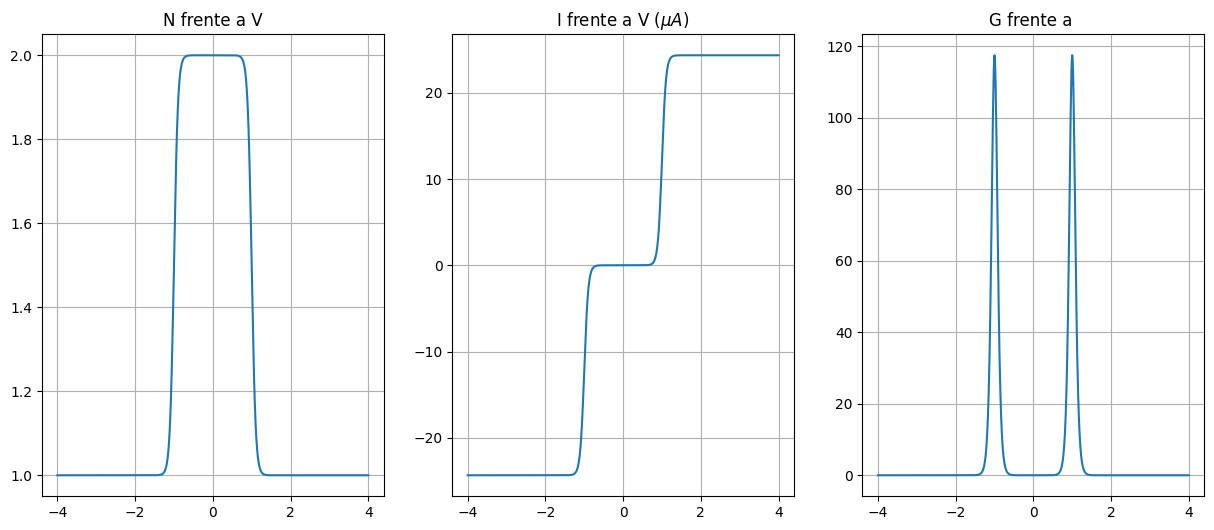

In [16]:
### PLOTEO LOS RESULTADOS ###################

plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.plot(V,N, label = "N-V")
plt.title("N frente a V")
plt.grid()

plt.subplot(1,3,2)
plt.plot(V, I, label="I-V")
plt.title(r"I frente a V ($\mu A$)")
plt.grid()

plt.subplot(1,3,3)
plt.plot(V,G, label="G-V")
plt.title("G frente a ")
plt.grid()


#### Apartado b
**Hacer lo mismo pero ahora con $q^2/C_{ES} = 1$**

In [17]:
### Código con la convergencia del método iterativo ###########################################

#Defino una variable para que me deje poner límite a la simulación

maxiteracion = 1000 #Como mucho hará 1000 iteraciones
U = np.linspace(-Vmax, Vmax, numpasos)

for i, v in enumerate(V):
    
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    
    U_old = 0.0     #Variable auxiliar
    U_new = 0.0     #Variable auxiliar según las pistas
    error = 1.0      #Será la tolerancia que le ponga que tiene que ser menor que la variable 'precision'
    numiteracion = 0 #Cuenta el número de iteración en el que estoy
    
    #Hago un while porque así puede salir del bucle
    #De nuevo para la N como la densidad de estados es una delta no nos hace falta integrar
    
    while error>precision and numiteracion < maxiteracion:
        
        #Plan de acción: Calculo N con U_old, calculo U con esa N, calculo U_new según me dicen las pistas y calculo el nuevo error
        
        Num_e = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo+U_old,mu_s) + Tau_s*fermi(homo + U_old, mu_d))
        U_aux = 1*(Num_e - N_0)
        U_new = U_old + alfa*(U_aux-U_old)
        error = np.abs(U_new-U_old)
        
        #Ahora actualizo y cambio de iteración.
        U_old = U_new
        numiteracion+=1
    
    #Se supone que ya ha convergido, así que guardo lo obtenido
    
    
    U[i] = U_old #Puedo poner aquí U_new o U_old, porque a la hora de terminar son iguales.
    N[i] = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo+U_old,mu_s) + Tau_s*fermi(homo + U_old, mu_d))
    

#Como recomendación del profesor, calcular la intensidad una vez calculada N y U

for i, v in enumerate(V):
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    I[i] = 2*q*(fermi(homo+U[i], mu_s)-fermi(homo+U[i],mu_d))/(Tau_d+Tau_s)*10**6
    

G = np.gradient(I,V)
    


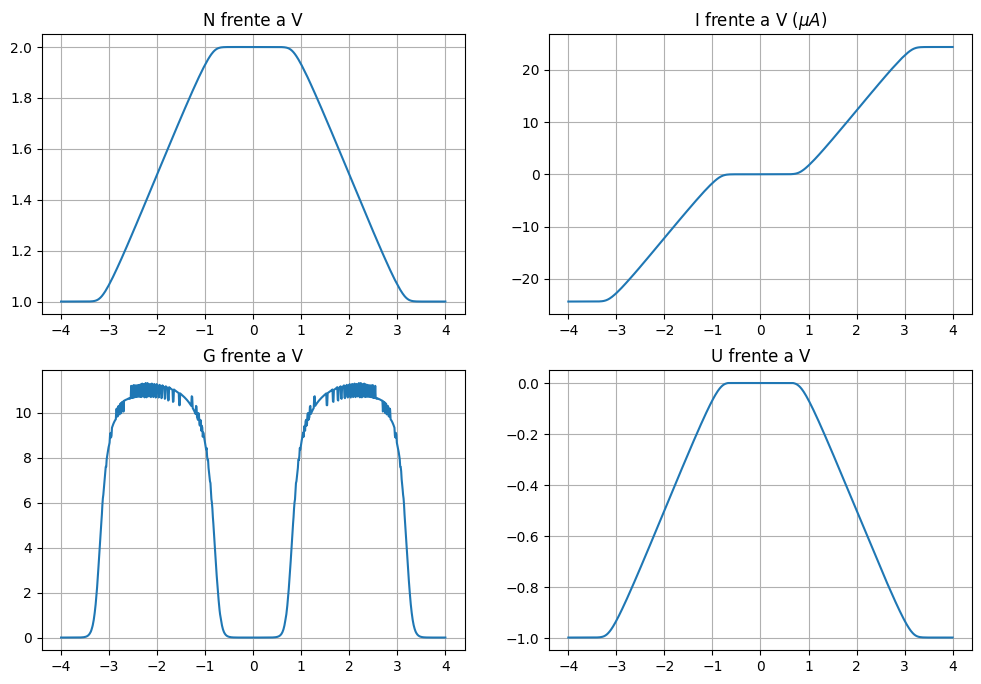

In [18]:
### PLOTEO LOS RESULTADOS ###################

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(V,N, label = "N-V")
plt.title("N frente a V")
plt.grid()

plt.subplot(2,2,2)
plt.plot(V, I, label="I-V")
plt.title(r"I frente a V ($\mu A$)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(V,G, label="G-V")
plt.title("G frente a V")
plt.grid()

plt.subplot(2,2,4)
plt.plot(V,U, label="U-V")
plt.title("U frente a V")
plt.grid()

#### Apartado c
**Explicar el origen de la banda prohibida de la conductancia. ¿Qué determina su magnitud?**

La banda prohibida de conductancia se da porque el nivel de HOMO está por debajo de ambos niveles de fermi de los metales $\mu_s$ y $\mu_d$. Hasta que no incrementamos el voltaje lo suficiente para que esté por encima de alguno de ellos no tenemos corriente pues los electrones no pueden pasar. La ventana de voltaje depende de U (osea de $C_{ES}$) y de la diferencia de niveles de fermi entre los metales y la molécula. Su magnitud la determina la variación de la intensidad, ya que se define como una derivada de la intensidad y esta derivada viene definida por la temperatura y por U. Cuanto menores son, más función escalon es la intensidad por lo que llegamos a una valor pico más alto en la conductancia.

#### Apartado d
**Escribe una expresión analítica para cuando $q^2/C_{ES}=0$**

Tenemos que cuando $q^2/C{ES}=0$ es porque $C_{ES}$ --> $\infty$, por tanto U=0.

Si U=0 tenemos la expresión para la corriente:
$$ I = 2q \frac{f(E,\mu_s)-f(E,\mu_D)}{\tau_s+\tau_D} $$

Esto se maximiza cuando $f(E, \mu_D) = 0$ y $f(E, \mu_S) = 1$. También lo hace cuando $\tau_S = \tau_D$ --> $\eta = 0.5$ Lo que nos lleva a:

$$I = \frac{q}{\tau_s}$$

#### Apartado e
**Explica por qué la conductancia es tan baja cuando U ya no es nula**

Como he dicho, la intensidad deja de ser una función escalón (o casi), sino que ahora es una función de E y de U. Esto provoca que la pendiente se haga más baja, por lo que se reduce su derivada y por tanto la conductancia.

Como lo veo yo es que hace falta 'más energía' para pasar otro electrón más si 'ya hay uno' en el nivel del homo. Por tanto la intensidad ya no es una función de que pasen o no pasen, depende del número de electrones 'que haya' y por tanto se verá reducida según su cantidad. Como lo que esto provoca es un descenso progresivo, la conductancia será menor.

### Ejercicio 2: Realizar el ejercicio 3.10

In [19]:
### Código para el ejercicio 3.10 ##########################


#Lo único nuevo es el LUMO. Como sabemos que está a cierto nivel, tenemos que poner la condición de tras cierto voltaje se active y que tiene un N0 =0
#Aún así, calcularé N0 con fermi, y haré el resultado final de la suma de ambos casos. Seguimos considerando deltas de densidad así que no tendremos problema.


#Pongo también un nuevo V_max para poder verlo bien

Vmax = 8.0


U = np.linspace(-Vmax, Vmax, numpasos)

#Calculo bien el N_0 con fermi
N_0 = 2.0/(Tau_d+Tau_s)*((Tau_d*fermi(homo,mu_s0) + Tau_s*fermi(homo , mu_d0))+(Tau_d*fermi(lumo,mu_s0) + Tau_s*fermi(lumo , mu_d0)))

for i, v in enumerate(V):
    
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    
    U_old = 0.0     #Variable auxiliar
    U_new = 0.0     #Variable auxiliar según las pistas
    error = 1.0      #Será la tolerancia que le ponga que tiene que ser menor que la variable 'precision'
    numiteracion = 0 #Cuenta el número de iteración en el que estoy
    
    #Hago un while porque así puede salir del bucle
    #De nuevo para la N como la densidad de estados es una delta no nos hace falta integrar
    
    while error>precision and numiteracion < maxiteracion:
        
        #Plan de acción: Calculo N con U_old, calculo U con esa N, calculo U_new según me dicen las pistas y calculo el nuevo error
        
        Num_e_homo = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo+U_old,mu_s) + Tau_s*fermi(homo + U_old, mu_d))
        Num_e_lumo = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(lumo+U_old,mu_s) + Tau_s*fermi(lumo + U_old, mu_d))
        Num_e = Num_e_homo + Num_e_lumo
        
        
        
        U_aux = 1*(Num_e - N_0)
        U_new = U_old + alfa*(U_aux-U_old)
        error = np.abs(U_new-U_old)
        
        #Ahora actualizo y cambio de iteración.
        U_old = U_new
        numiteracion+=1
    
    #Se supone que ya ha convergido, así que guardo lo obtenido
    
    
    U[i] = U_old #Puedo poner aquí U_new o U_old, porque a la hora de terminar son iguales.
    N[i] = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo+U_old,mu_s) + Tau_s*fermi(homo + U_old, mu_d) + Tau_d*fermi(lumo+U_old,mu_s) + Tau_s*fermi(lumo + U_old, mu_d))
    

#Como recomendación del profesor, calcular la intensidad una vez calculada N y U

for i, v in enumerate(V):
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    I[i] = 2*q/(Tau_d+Tau_s)*10**6*((fermi(homo+U[i], mu_s)-fermi(homo+U[i],mu_d))+(fermi(lumo+U[i], mu_s)-fermi(lumo+U[i],mu_d)))
    

G = np.gradient(I,V)
    


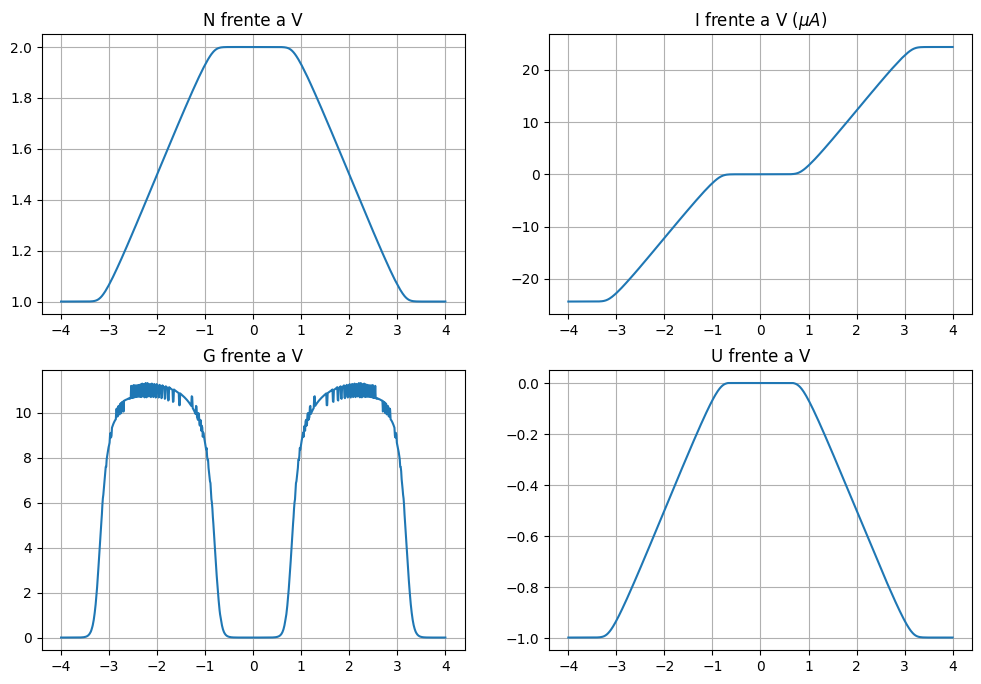

In [20]:
### PLOTEO LOS RESULTADOS ###################

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(V,N, label = "N-V")
plt.title("N frente a V")
plt.grid()

plt.subplot(2,2,2)
plt.plot(V, I, label="I-V")
plt.title(r"I frente a V ($\mu A$)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(V,G, label="G-V")
plt.title("G frente a V")
plt.grid()

plt.subplot(2,2,4)
plt.plot(V,U, label="U-V")
plt.title("U frente a V")
plt.grid()

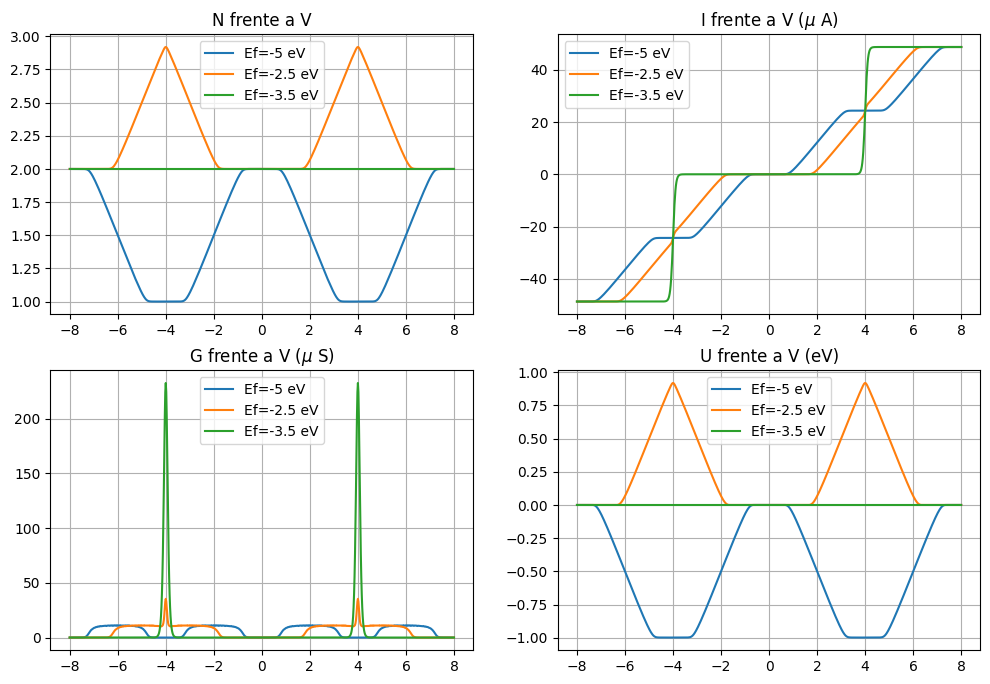

In [21]:
### Código para varios casos de Ef y ploteo directo ###############################################



#Repito exactamente lo mismo pero con Ef siendo una lista, por lo que tenemos que añadir un bucle más.

Ef_list = [-5, -2.5, -3.5]

#Creo el ploteo para ir poniendo las curvas conforme aparezcan

plt.figure(figsize=(12,8))

Vmax = 8.0
V = np.linspace(-Vmax, Vmax, numpasos)
N = np.linspace(-Vmax, Vmax, numpasos)
I = np.linspace(-Vmax, Vmax, numpasos)
U = np.linspace(-Vmax, Vmax, numpasos)

#Hago el gran bucle

for EFermi in Ef_list:

    #Recalculo los valores iniciales
    mu_s0=EFermi
    mu_d0=EFermi
    N_0 = 2.0/(Tau_d+Tau_s)*((Tau_d*fermi(homo,mu_s0) + Tau_s*fermi(homo , mu_d0))+(Tau_d*fermi(lumo,mu_s0) + Tau_s*fermi(lumo , mu_d0)))
    

    
    for i, v in enumerate(V):
        mu_s = mu_s0 + Eta*v
        mu_d = mu_d0 -(1-Eta)*v
    
        U_old = 0.0     #Variable auxiliar
        U_new = 0.0     #Variable auxiliar según las pistas
        error = 1.0      #Será la tolerancia que le ponga que tiene que ser menor que la variable 'precision'
        numiteracion = 0 #Cuenta el número de iteración en el que estoy
    
        #Hago un while porque así puede salir del bucle
        #De nuevo para la N como la densidad de estados es una delta no nos hace falta integrar
    
        while error>precision and numiteracion < maxiteracion:
        
        #Plan de acción: Calculo N con U_old, calculo U con esa N, calculo U_new según me dicen las pistas y calculo el nuevo error
        
            Num_e_homo = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo+U_old,mu_s) + Tau_s*fermi(homo + U_old, mu_d))
            Num_e_lumo = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(lumo+U_old,mu_s) + Tau_s*fermi(lumo + U_old, mu_d))
            Num_e = Num_e_homo + Num_e_lumo
        
        
        
            U_aux = 1*(Num_e - N_0)
            U_new = U_old + alfa*(U_aux-U_old)
            error = np.abs(U_new-U_old)
            
            #Ahora actualizo y cambio de iteración.
            U_old = U_new
            numiteracion+=1
        
        #Se supone que ya ha convergido, así que guardo lo obtenido
        
        
        U[i] = U_old #Puedo poner aquí U_new o U_old, porque a la hora de terminar son iguales.
        N[i] = 2.0/(Tau_d+Tau_s)*(Tau_d*fermi(homo+U_old,mu_s) + Tau_s*fermi(homo + U_old, mu_d) + Tau_d*fermi(lumo+U_old,mu_s) + Tau_s*fermi(lumo + U_old, mu_d))
    

    #Como recomendación del profesor, calcular la intensidad una vez calculada N y U

    for i, v in enumerate(V):
        mu_s = mu_s0 + Eta*v
        mu_d = mu_d0 -(1-Eta)*v
        I[i] = 2*q/(Tau_d+Tau_s)*10**6*((fermi(homo+U[i], mu_s)-fermi(homo+U[i],mu_d))+(fermi(lumo+U[i], mu_s)-fermi(lumo+U[i],mu_d)))
        

    G = np.gradient(I,V)
    
    plt.subplot(2,2,1)
    plt.plot(V,N, label =f"Ef={EFermi} eV")

    plt.subplot(2,2,2)
    plt.plot(V, I, label=f"Ef={EFermi} eV")

    plt.subplot(2,2,3)
    plt.plot(V,G, label=f"Ef={EFermi} eV")

    plt.subplot(2,2,4)
    plt.plot(V,U, label=f"Ef={EFermi} eV")


plt.subplot(2,2,1)
plt.title("N frente a V")
plt.grid()
plt.legend()

plt.subplot(2,2,2)
plt.title(r"I frente a V ($\mu$ A)")
plt.grid()
plt.legend()

plt.subplot(2,2,3)
plt.title(r"G frente a V ($\mu$ S)")
plt.grid()
plt.legend()

plt.subplot(2,2,4)
plt.title("U frente a V (eV)")
plt.grid()
plt.legend()

#### Apartado d
**¿Por qué son las caracteristicas corriente-voltaje uniformes? Identifica el origen de las transiciones en la curva IV**

Son uniformes por la razón que nos pone la pista, nuestro parámetro $\eta$ es 0.5, osea los electrones 'tardan lo mismo' en salir que en entrar. De no ser 0.5 las curvas se verían desplazadas, la conductancia ya no sería simétrica y dependería de si es más 1 o más 0 que se desplazarían más al contacto S o al D.

#### Apartado e
**Por qué el efecto de carga está ausente con Ef = -3.5 eV**

3.5 es la media entre 5.5 y 1.5 que son el Homo y el Lumo respectivamente. Tenemos inicialmente en estos casos que N_0 para el Lumo será 0 y para el homo será 2. Cuando se activan, es decir, que $\mu_s$ está por encima del lumo y $\mu_D$ por debajo del homo o al revés, el lumo 'ganaría 1 electrón' pero es que el homo lo daría al drenador. Por tanto el número total de electrones no cambia, se mantiene constante --> no hay efectos de carga si no aumenta el número de electrones.